# Credit Risk Prediction

## End-to-End Data Analytics Project

### Technologies
- Python
- Pandas
- Scikit-Learn
- MongoDB Atlas
- Power BI

### Project Objectives

This project demonstrates an end-to-end analytics workflow for predicting credit risk using machine learning techniques. The workflow includes data cleaning, feature engineering, cloud database integration with MongoDB Atlas, model development, evaluation, and business intelligence visualization using Power BI.

In [ ]:
!pip install pymongo scikit-learn pandas numpy matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("credit_risk_dataset[1].csv")

df.head()

Saving credit_risk_dataset.csv to credit_risk_dataset.csv


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
print("Filas y columnas:", df.shape)

print("\nColumnas del dataset:")
print(df.columns)

print("\nInformación general:")
df.info()

print("\nValores nulos por columna:")
print(df.isnull().sum())

Filas y columnas: (32581, 12)

Columnas del dataset:
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate 

In [ ]:
print("Distribución de loan_status:")
print(df["loan_status"].value_counts())

print("\nPorcentaje:")
print(df["loan_status"].value_counts(normalize=True) * 100)

Distribución de loan_status:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Porcentaje:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


In [ ]:
# ==========================================
# Data Cleaning
# ==========================================

# Create a copy of the original dataset
df_clean = df.copy()

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Filter unrealistic ages
df_clean = df_clean[
    (df_clean["person_age"] >= 18) &
    (df_clean["person_age"] <= 100)
]

# Filter unrealistic employment length
df_clean = df_clean[
    (df_clean["person_emp_length"].isna()) |
    (df_clean["person_emp_length"] <= 60)
]

# Fill missing numerical values using the median
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values using the mode
categorical_cols = df_clean.select_dtypes(include=["object"]).columns

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Display data cleaning summary
print("=" * 50)
print("DATA CLEANING SUMMARY")
print("=" * 50)

print(f"Original dataset shape : {df.shape}")
print(f"Cleaned dataset shape  : {df_clean.shape}")

print("\nMissing values after data cleaning:")
print(df_clean.isnull().sum())

In [ ]:
# ==========================================
# Feature Engineering for Business Intelligence
# ==========================================

# Create a copy of the cleaned dataset
df_bi = df_clean.copy()

# Create risk labels for better interpretation of the target variable
df_bi["risk_label"] = df_bi["loan_status"].map({
    0: "No Default",
    1: "High Risk"
})

# Create labels for previous default history
df_bi["default_history_label"] = df_bi["cb_person_default_on_file"].map({
    "Y": "Previous Default",
    "N": "No Previous Default"
})

# Create age groups
df_bi["age_group"] = pd.cut(
    df_bi["person_age"],
    bins=[18, 25, 35, 45, 60, 100],
    labels=["18-25", "26-35", "36-45", "46-60", "60+"],
    include_lowest=True
)

# Create income groups
df_bi["income_group"] = pd.cut(
    df_bi["person_income"],
    bins=[0, 25000, 50000, 75000, 100000, 999999999],
    labels=["Low", "Lower Middle", "Middle", "Upper Middle", "High"]
)

# Display the transformed dataset
df_bi.head()

In [ ]:
# ==========================================
# Export Dataset to JSON
# ==========================================

# Export the processed dataset to JSON format
df_bi.to_json(
    "credit_risk_dataset.json",
    orient="records",
    force_ascii=False
)

# Download the JSON file
files.download("credit_risk_dataset.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# Export Dataset for Power BI
# ==========================================

# Export the processed dataset to CSV format
# for Power BI visualization

df_bi.to_csv(
    "credit_risk_clean_powerbi.csv",
    index=False
)

# Download the dataset
files.download("credit_risk_clean_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# Connect to MongoDB Atlas
# ==========================================

from pymongo import MongoClient
from getpass import getpass
from urllib.parse import quote_plus

# MongoDB Atlas credentials
username = "<YOUR_USERNAME>"

password = getpass("Enter your MongoDB Atlas password: ")
password_encoded = quote_plus(password)

cluster = "<YOUR_CLUSTER>.mongodb.net"

# Build MongoDB connection string
uri = (
    f"mongodb+srv://{username}:{password_encoded}"
    f"@{cluster}/?retryWrites=true&w=majority"
)

# Create MongoDB client
client = MongoClient(uri)

# Verify connection
client.admin.command("ping")

print("Successfully connected to MongoDB Atlas")

In [ ]:
# ==========================================
# Upload Dataset to MongoDB Atlas
# ==========================================

# Select database and collection
db = client["credit_risk_db"]
collection = db["loan_applications"]

# Convert DataFrame to a list of dictionaries
records = df_bi.to_dict(orient="records")

# Clear the collection to avoid duplicate records
collection.delete_many({})

# Insert processed records into MongoDB Atlas
collection.insert_many(records)

# Display upload summary
print("=" * 50)
print("MONGODB UPLOAD SUMMARY")
print("=" * 50)
print(f"Documents uploaded: {collection.count_documents({})}")

In [ ]:
# ==========================================
# Retrieve Dataset from MongoDB Atlas
# ==========================================

# Retrieve all documents (excluding MongoDB ObjectId)
data_from_mongo = list(
    collection.find({}, {"_id": 0})
)

# Convert documents into a DataFrame
df_mongo = pd.DataFrame(data_from_mongo)

# Display retrieval summary
print("=" * 50)
print("DATA RETRIEVAL SUMMARY")
print("=" * 50)
print(f"Dataset shape: {df_mongo.shape}")

# Display the first records
df_mongo.head()

In [ ]:
#Crear documento para subir en Power BI
df_mongo.to_csv("credit_risk_from_mongodb_powerbi.csv", index=False)

files.download("credit_risk_from_mongodb_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================================
# Machine Learning Data Preparation
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Columns used only for Power BI labels or derived business categories
cols_to_drop = [
    "loan_status",
    "risk_label",
    "default_history_label",
    "age_group",
    "income_group"
]

# Define predictors and target variable
X = df_mongo.drop(columns=cols_to_drop)
y = df_mongo["loan_status"]

# Identify numerical and categorical features
categorical_features = X.select_dtypes(include=["object"]).columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

print("=" * 50)
print("FEATURE SUMMARY")
print("=" * 50)

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

# Define preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 50)
print("TRAIN / TEST SPLIT SUMMARY")
print("=" * 50)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape : {X_test.shape}")

In [ ]:
# ==========================================
# Logistic Regression Model
# ==========================================

# Build the machine learning pipeline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Train the model
log_model.fit(X_train, y_train)

# Generate predictions
y_pred_log = log_model.predict(X_test)

# ==========================================
# Logistic Regression Evaluation
# ==========================================

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

In [ ]:
# ==========================================
# Random Forest Model
# ==========================================

# Build the machine learning pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

# ==========================================
# Random Forest Evaluation
# ==========================================

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

In [ ]:
# ==========================================
# Confusion Matrix Visualization
# ==========================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize
import matplotlib as mpl

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Semantic color mapping
color_matrix = np.array([
    [0, 1],
    [1, 2]
])

cmap_matrix = ListedColormap([
    "#6EF052",  # True Negative
    "#F2E84A",  # Misclassification
    "#E53935"   # True Positive
])

bounds = [-0.5, 0.5, 1.5, 2.5]
norm_matrix = BoundaryNorm(bounds, cmap_matrix.N)

fig, ax = plt.subplots(figsize=(7, 5))

ax.imshow(color_matrix, cmap=cmap_matrix, norm=norm_matrix)

# Chart title and labels
ax.set_title("Random Forest - Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")

# Axis labels
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Default", "High Risk"])

ax.set_yticks([0, 1])
ax.set_yticklabels(["No Default", "High Risk"])

# Display values inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white",
            fontsize=13,
            fontweight="bold"
        )

# Create color scale
norm_counts = Normalize(vmin=0, vmax=cm.max())

cmap_bar = mpl.colors.LinearSegmentedColormap.from_list(
    "case_count",
    ["#6EF052", "#F2E84A", "#E53935"]
)

sm = mpl.cm.ScalarMappable(
    cmap=cmap_bar,
    norm=norm_counts
)

sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(
    "Number of Cases",
    rotation=270,
    labelpad=18
)

cbar.set_ticks([0, 1000, 2000, 3000, 4000, 5000])

plt.tight_layout()
plt.show()

## Model Interpretation

The Random Forest model achieved the highest predictive performance among the evaluated models.

The confusion matrix shows a strong ability to correctly identify both low-risk and high-risk applicants while maintaining a balanced classification performance.

This visualization provides an intuitive interpretation of model predictions and supports decision-making for credit risk assessment.

In [ ]:
# ==========================================
# Feature Importance Analysis
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Retrieve feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Retrieve feature importance scores from the Random Forest model
importances = rf_model.named_steps["classifier"].feature_importances_

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort features by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("=" * 50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("=" * 50)

# Display the top 10 features
feature_importance.head(10)

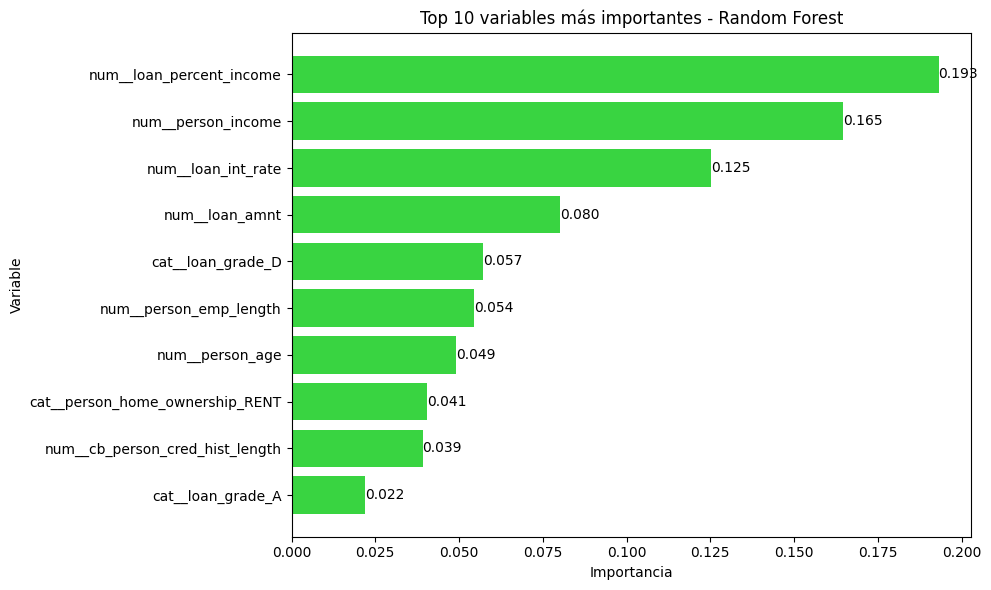

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_features["Variable"],
    top_features["Importancia"],
    color="#39d441"
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 10 variables más importantes - Random Forest")
plt.gca().invert_yaxis()

# Mostrar valores al lado de cada barra
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Top 10 Most Important Features
# ==========================================

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="#39d441"
)

plt.title(
    "Top 10 Most Important Features - Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")

# Display the most important feature at the top
plt.gca().invert_yaxis()

# Display importance values
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.001,
        bar.get_y() + bar.get_height()/2,
        f"{width:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Credit Risk Distribution
# ==========================================

status_counts = df_mongo["risk_label"].value_counts()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    status_counts.index,
    status_counts.values,
    color=["#39d441", "#e32727"]
)

plt.title(
    "Customer Credit Risk Distribution",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

# Display values above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Export Dataset for Power BI
# ==========================================

df_mongo.to_csv(
    "credit_risk_from_mongodb_powerbi.csv",
    index=False
)

files.download("credit_risk_from_mongodb_powerbi.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusions

## Key Results

- Successfully built an end-to-end credit risk prediction pipeline.
- Integrated MongoDB Atlas with Python.
- Compared Logistic Regression and Random Forest models.
- Random Forest achieved the best predictive performance.
- Created a Power BI dashboard for business reporting.

## Skills Demonstrated

- Python
- Machine Learning
- MongoDB Atlas
- Power BI
- Data Cleaning
- Feature Engineering
- Data Visualization